# Phase 9 — Seasonality & Trend Analysis (Use Case 3)

**คำถามธุรกิจ:** ยอดขายที่ผันผวนของแต่ละหมวดหมู่สินค้า มาจากฤดูกาล/แนวโน้มมากแค่ไหน เทียบกับปัจจัยอื่น และแตกต่างกันไปตามหมวดหมู่หรือไม่?

**วิธีที่ใช้:** STL decomposition (Seasonal-Trend decomposition using LOESS) — แยกอนุกรมเวลาของยอดขายรวมแต่ละหมวดหมู่ (รวมทุก SKU/channel/region ในหมวดนั้น) ออกเป็น 3 ส่วน:
- **Trend** — แนวโน้มระยะยาว
- **Seasonal** — รูปแบบที่เกิดซ้ำทุกปี (period = 52 สัปดาห์)
- **Residual** — สิ่งที่เหลือหลังหักสองส่วนแรกออก (เช่น โปรโมชัน, เหตุการณ์เฉพาะกิจ, noise)

ใช้ `robust=True` เพื่อลดผลกระทบจากค่าผิดปกติ (outlier) ที่อาจเกิดจากสัปดาห์ที่มีโปรโมชันหนักผิดปกติ


In [ ]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
cat_weekly = df.groupby(['category', 'week']).units_sold.sum().reset_index()
categories = sorted(cat_weekly.category.unique())
print('categories:', categories)


categories: ['Juice', 'Milk', 'ReadyMeal', 'SnackBar', 'Yogurt']


## 1. รัน STL แยกทีละหมวดหมู่


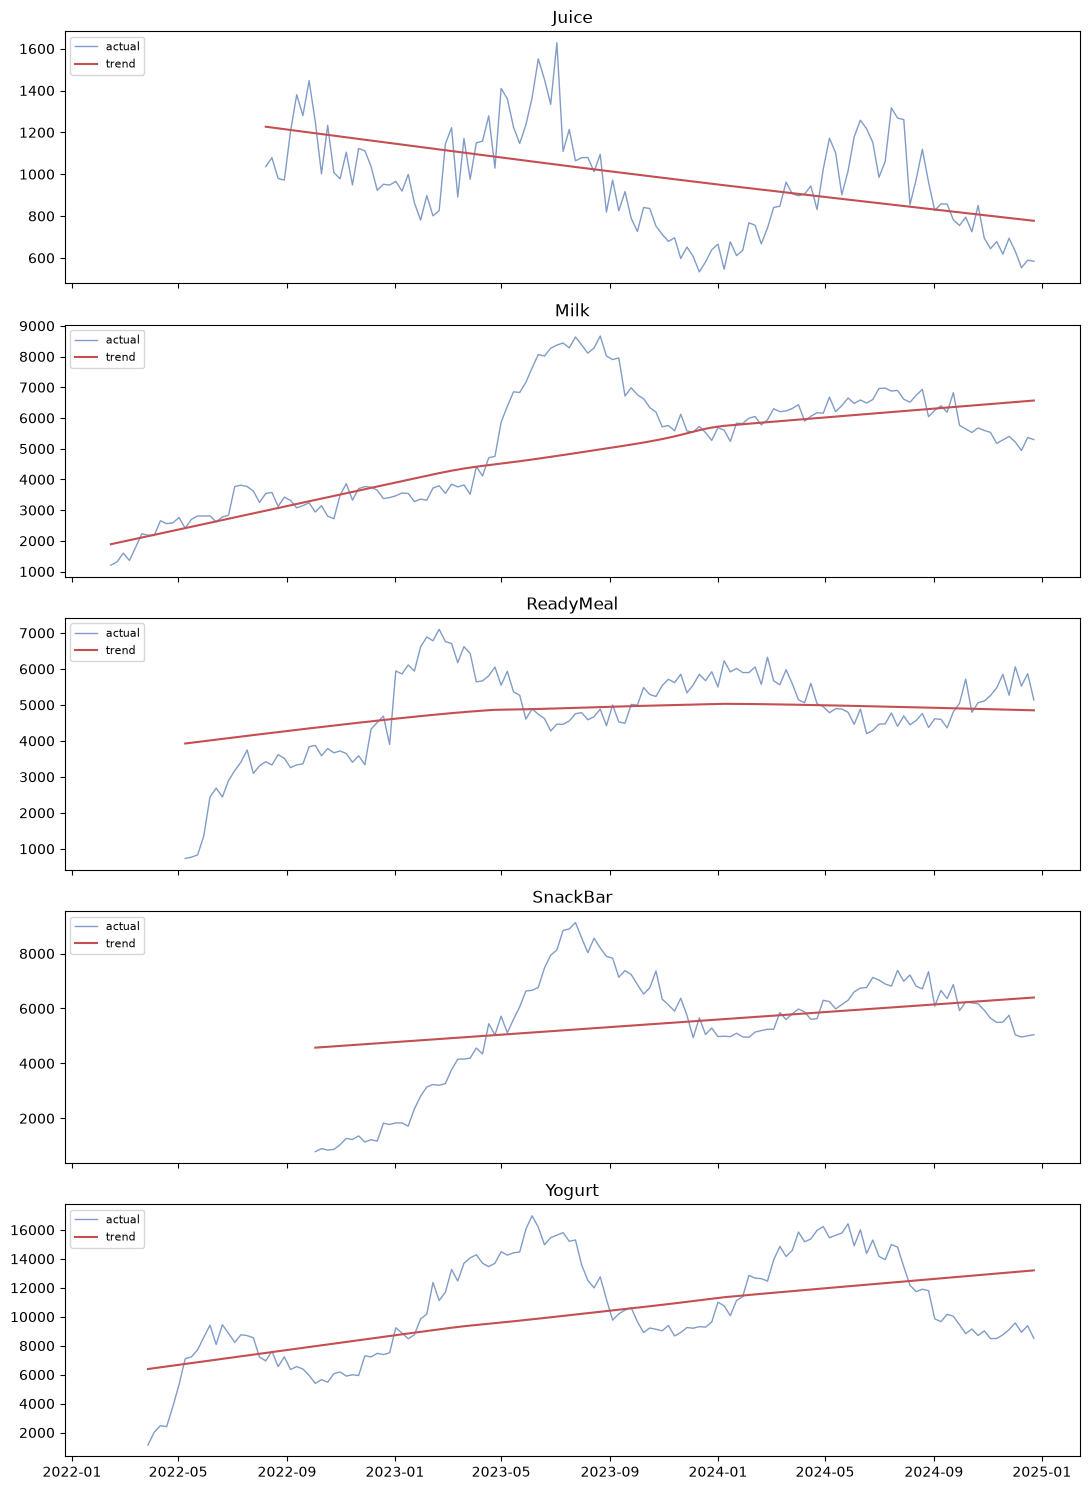

In [ ]:
stl_results = {}
for cat in categories:
    s = cat_weekly[cat_weekly.category == cat].set_index('week')['units_sold'].asfreq('W-MON')
    s = s.interpolate()  # เติมสัปดาห์ที่ขาดหาย (ถ้ามี) ด้วยการ interpolate เชิงเส้น ก่อนป้อนเข้า STL ซึ่งต้องการอนุกรมต่อเนื่อง
    stl_results[cat] = STL(s, period=52, robust=True).fit()

fig, axes = plt.subplots(len(categories), 1, figsize=(11, 3 * len(categories)), sharex=True)
for ax, cat in zip(axes, categories):
    s = cat_weekly[cat_weekly.category == cat].set_index('week')['units_sold']
    ax.plot(s.index, s.values, color='#4C72B0', linewidth=1, alpha=0.7, label='actual')
    ax.plot(stl_results[cat].trend.index, stl_results[cat].trend.values, color='#C44E52', linewidth=1.5, label='trend')
    ax.set_title(cat)
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/figures/phase9_stl_trend_overview.png', dpi=120)
plt.show()


## 2. สัดส่วนความผันผวนที่อธิบายได้ (Variance Share)

คำนวณสัดส่วนความแปรปรวน (variance) ของแต่ละส่วนประกอบเทียบกับความแปรปรวนรวมของอนุกรมต้นฉบับ — ตัวเลขนี้บอกว่า **ฤดูกาลอธิบายความผันผวนของยอดขายได้กี่ %** เทียบกับแนวโน้มระยะยาวและส่วนที่เหลือ (หมายเหตุ: ผลรวม 3 สัดส่วนไม่จำเป็นต้องเท่ากับ 100% เป๊ะ เพราะ trend/seasonal/residual ไม่ได้เป็นอิสระต่อกันทางสถิติเสมอไป)


In [ ]:
rows = []
for cat in categories:
    res = stl_results[cat]
    var_total = np.var(res.observed)
    rows.append({
        'category': cat,
        'n_weeks': len(res.observed),
        'seasonal_share': np.var(res.seasonal) / var_total,
        'trend_share': np.var(res.trend) / var_total,
        'resid_share': np.var(res.resid) / var_total,
    })

variance_shares = pd.DataFrame(rows).sort_values('seasonal_share', ascending=False).reset_index(drop=True)
variance_shares.round(3)


,category,n_weeks,seasonal_share,trend_share,resid_share
0,SnackBar,117,0.869,0.067,0.234
1,ReadyMeal,138,0.757,0.066,0.153
2,Juice,125,0.726,0.298,0.116
3,Yogurt,144,0.534,0.324,0.211
4,Milk,150,0.083,0.575,0.284


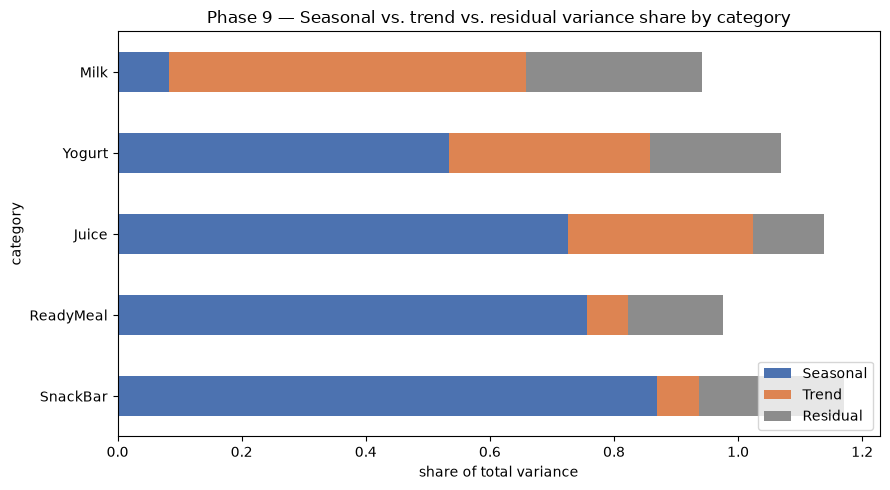

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = variance_shares.set_index('category')[['seasonal_share', 'trend_share', 'resid_share']]
plot_df.plot(kind='barh', stacked=True, ax=ax, color=['#4C72B0', '#DD8452', '#8C8C8C'])
ax.set_xlabel('share of total variance')
ax.set_title('Phase 9 — Seasonal vs. trend vs. residual variance share by category')
ax.legend(['Seasonal', 'Trend', 'Residual'], loc='lower right')
plt.tight_layout()
plt.savefig('../reports/figures/phase9_variance_shares.png', dpi=120)
plt.show()


## 3. Robustness Check: แนวโน้มของ Milk เป็น SKU-count Growth Artifact จริงหรือไม่?

Section 1-2 คำนวณ STL จาก **ผลรวม (sum)** ยอดขายทุก SKU ในหมวดหมู่ ซึ่งจะเพิ่มขึ้นเองโดยอัตโนมัติถ้ามี SKU ใหม่มาเปิดตัวเพิ่มในหมวดนั้น (ไม่เกี่ยวกับว่าลูกค้าซื้อต่อ SKU มากขึ้นจริงหรือเปล่า) — ปัญหาเดียวกับที่ Phase 4 เคยเจอตอนสร้างฟีเจอร์ `category_trend` และแก้ด้วยการใช้**ค่าเฉลี่ยต่อ SKU-channel-region แทนผลรวม** (ดู `src/features/enrich.py::compute_category_trend`) ที่นี่ rerun STL แบบเดียวกันแต่ใช้ **ค่าเฉลี่ย (mean)** แทน sum เพื่อดูว่าสัดส่วน trend/seasonal เปลี่ยนไปแค่ไหนเมื่อตัดผลของจำนวน SKU ที่เพิ่มขึ้นออก โดยเฉพาะ Milk ที่จำนวน SKU active เพิ่มจาก 2 เป็น 7 ตัวตลอดช่วงข้อมูล


In [ ]:
sku_active = df.groupby(['category', 'week']).sku.nunique().reset_index()
cat_weekly_mean = df.groupby(['category', 'week']).units_sold.mean().reset_index()

stl_results_mean = {}
for cat in categories:
    s = cat_weekly_mean[cat_weekly_mean.category == cat].set_index('week')['units_sold'].asfreq('W-MON')
    s = s.interpolate()
    stl_results_mean[cat] = STL(s, period=52, robust=True).fit()

rows = []
for cat in categories:
    res = stl_results_mean[cat]
    var_total = np.var(res.observed)
    sku_start = int(sku_active[sku_active.category == cat].sku.iloc[0])
    sku_end = int(sku_active[sku_active.category == cat].sku.iloc[-1])
    prior = variance_shares.set_index('category').loc[cat]
    rows.append({
        'category': cat,
        'sku_count_start_to_end': f'{sku_start} -> {sku_end}',
        'trend_share_SUM': prior['trend_share'],
        'trend_share_MEAN': np.var(res.trend) / var_total,
        'seasonal_share_SUM': prior['seasonal_share'],
        'seasonal_share_MEAN': np.var(res.seasonal) / var_total,
    })

robustness_check = pd.DataFrame(rows).sort_values('category').reset_index(drop=True)
robustness_check.round(3)


,category,sku_count_start_to_end,trend_share_SUM,trend_share_MEAN,seasonal_share_SUM,seasonal_share_MEAN
0,Juice,1 -> 1,0.298,0.298,0.726,0.726
1,Milk,2 -> 7,0.575,0.220,0.083,0.703
2,ReadyMeal,1 -> 5,0.066,0.161,0.757,0.882
3,SnackBar,1 -> 6,0.067,0.439,0.869,0.925
4,Yogurt,1 -> 11,0.324,0.065,0.534,0.951


## 4. ข้อสังเกตรายหมวดหมู่

- **SnackBar และ ReadyMeal** — สัดส่วนฤดูกาลสูงมาก (~76-87% ของความผันผวนในมุมมอง sum และยังคงสูงในมุมมอง per-SKU mean ด้วย — ดู robustness check ในข้อ 3) แปลว่ายอดขายของสองหมวดนี้ผันผวนตามช่วงเวลาของปีเป็นหลัก (เช่น เทศกาล, ฤดูกาลบริโภค) มากกว่าจะเป็นแนวโน้มระยะยาวหรือปัจจัยสุ่ม
- **Juice** — สัดส่วนฤดูกาลสูงเช่นกัน (~73%) แต่ต้องตีความอย่างระวังเพราะมีแค่ 1 SKU (JU-021) เป็นตัวแทนทั้งหมวด และมีประวัติสั้นกว่าหมวดอื่น (125 สัปดาห์ เทียบกับ 150 สัปดาห์ของหมวดอื่น) — เพราะมีแค่ 1 SKU ตัวเลข sum และ mean จึงเหมือนกันเป๊ะ (0.726 ทั้งคู่) ซึ่งใช้เป็น sanity check ได้ด้วยว่าวิธี mean ใน robustness check ทำงานถูกต้อง
- **Yogurt** — ในมุมมอง sum สัดส่วนฤดูกาล/แนวโน้มใกล้เคียงกัน (53%/32%) แต่ในมุมมอง per-SKU mean สัดส่วนแนวโน้มลดลงมาก (32%→6.5%) และฤดูกาลเพิ่มเป็น 95% — สอดคล้องกับการมี SKU มากที่สุด (1→11 ตัว) ที่ทยอยเปิดตัวเพิ่มเรื่อยๆ ยิ่งตอกย้ำว่า "แนวโน้ม" ที่เห็นในมุมมอง sum ส่วนใหญ่มาจากจำนวน SKU ที่เพิ่มขึ้น ไม่ใช่ demand ต่อ SKU ที่โตขึ้นจริง
- **Milk — ข้อสรุปเดิมต้องแก้ไข:** ในมุมมอง sum (แบบเดิม) แนวโน้มดูครอบงำ (57.5%) มากกว่าฤดูกาล (8.3%) แต่หลัง robustness check (per-SKU mean, ตัดผล SKU-count growth 2→7 ตัวออก) **ตัวเลขกลับด้านสิ้นเชิง**: ฤดูกาลกลายเป็นตัวขับเคลื่อนหลัก (70.3%) ส่วนแนวโน้มลดลงเหลือ 22.0% — สรุปว่า **สิ่งที่ดูเหมือน "แนวโน้มเติบโต" ของนมใน sum view ส่วนใหญ่คือ SKU-count growth ไม่ใช่ demand ต่อ SKU ที่โตขึ้นจริง** นมจึงควรถูกจัดกลุ่มร่วมกับหมวดอื่นๆ ที่ขับเคลื่อนด้วยฤดูกาลเป็นหลัก ไม่ใช่ข้อยกเว้นอย่างที่เข้าใจตอนแรก

**ข้อควรระวังทั่วไป:** ผลจาก robustness check ไม่ได้เปลี่ยนไปทิศทางเดียวกันทุกหมวด (SnackBar/ReadyMeal สัดส่วนแนวโน้มกลับ*เพิ่มขึ้น*ในมุมมอง mean แม้ SKU จะเพิ่มเช่นกัน) จึงไม่ควรตีความมุมมอง mean ว่าเป็น "ความจริงที่แท้จริง" เสมอไปในทุกหมวด — mean series เองก็มี artifact ได้จากการเฉลี่ยข้าม SKU ที่จำนวนเปลี่ยนไปตามเวลา (เช่น ช่วงที่มีแค่ 1 SKU active ค่าเฉลี่ยจะเท่ากับค่าดิบของ SKU นั้นเลย มี noise เต็มที่ ก่อนจะเรียบขึ้นเมื่อมี SKU มาเฉลี่ยด้วยมากขึ้น) ข้อสรุปที่ confident ที่สุดจากการเช็คนี้คือเฉพาะกรณี **Milk** ที่สัญญาณกลับด้านชัดเจนมาก และมี Juice (1-SKU ตลอดทั้งช่วง) เป็น sanity check ยืนยันว่าวิธี mean ทำงานถูกต้อง

## 5. สรุป Phase 9

การผันผวนของยอดขาย**ไม่ได้มาจากฤดูกาลในสัดส่วนเท่ากันทุกหมวดหมู่** — SnackBar/ReadyMeal/Juice/Yogurt ขับเคลื่อนด้วยฤดูกาลเป็นหลักในทั้งสองมุมมอง (sum และ per-SKU mean) ส่วน **Milk เดิมดูเหมือนขับเคลื่อนด้วยแนวโน้มระยะยาว แต่ robustness check ในข้อ 3 ชี้ว่านั่นคือ SKU-count growth artifact เป็นหลัก — เมื่อตัดผลของจำนวน SKU ที่เพิ่มขึ้นออกแล้ว นมก็ขับเคลื่อนด้วยฤดูกาลเหมือนหมวดอื่นเช่นกัน** ข้อค้นพบนี้มีนัยเชิงธุรกิจที่ต่างจากที่เข้าใจตอนแรก: การวางแผนสต๊อกสำหรับ Milk **ไม่ควรเพิ่มสต๊อกต่อ SKU ตามแนวโน้มการเติบโตที่เข้าใจผิด** แต่ควรวางแผนแยกเป็น 2 เรื่อง — (1) เพิ่มจำนวน SKU ใหม่ในพอร์ตให้เหมาะสมกับดีมานด์ตลาด และ (2) วางแผนสต๊อกต่อ SKU ตามปฏิทินฤดูกาลเหมือนหมวดอื่นๆ ไม่ใช่ตามแนวโน้มเติบโตต่อชิ้นที่ไม่มีอยู่จริง
